# KNN Classification from Scratch
**Dataset:** Pima Indians Diabetes Dataset  
**Student ID:** 0112320065  
**Objective:** Implement KNN manually and evaluate for K = 1, 3, 5, 7

## Step 1 — Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Step 2 — Load the Dataset

In [33]:
# using np.genfromtxt since we can't use pandas
raw_data = np.genfromtxt('diabetes.csv', delimiter=',', skip_header=1)


## Step 3 — Separate Features and Labels, Then Normalize

In [35]:
# all columns except the last one are features
X = raw_data[:, :-1]
y = raw_data[:, -1]     # last column = Outcome (0 or 1)

# ---- Min-Max Normalization ----
# normalizing before distance calc so no single feature dominates
def normalize(X):
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    # small epsilon to avoid division by zero
    return (X - X_min) / (X_max - X_min + 1e-8)

X_norm = normalize(X)


## Step 4 — Train / Test Split (70 / 30)

In [18]:
# seed = student ID 0112320065
np.random.seed(112320065)

indices = np.arange(len(X_norm))
np.random.shuffle(indices)

split = int(0.8 * len(indices))

train_idx = indices[:split]
test_idx  = indices[split:]

X_train = X_norm[train_idx]
y_train = y[train_idx]
X_test  = X_norm[test_idx]
y_test  = y[test_idx]

print(f"Training samples : {len(X_train)}  ({len(X_train)/len(X_norm)*100:.1f}%)")
print(f"Testing  samples : {len(X_test)}   ({len(X_test)/len(X_norm)*100:.1f}%)")

Training samples : 614  (79.9%)
Testing  samples : 154   (20.1%)


## Step 5 — Euclidean Distance Function

In [19]:
def euclidean_distance(p1, p2):
    """
    Euclidean distance between two points p1 and p2.
    Formula: sqrt( sum( (p1_i - p2_i)^2 ) )
    """
    total = 0.0
    for a, b in zip(p1, p2):
        total += (a - b) ** 2
    return math.sqrt(total)

# quick sanity check
d = euclidean_distance([0, 0], [3, 4])
print("Distance between [0,0] and [3,4] should be 5.0 :", d)

Distance between [0,0] and [3,4] should be 5.0 : 5.0


## Step 6 — KNN Prediction (Single Test Point)

In [20]:
def knn_predict(X_train, y_train, test_point, k):
    # """
    # Predict the class label for a single test_point.
    # Steps:
    #   1. Compute distance to all training points
    #   2. Sort distances ascending
    #   3. Take k nearest neighbors
    #   4. Majority vote -> predicted class
    # """
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], test_point)
        distances.append((dist, y_train[i]))

    # sort by distance (ascending)
    distances.sort(key=lambda x: x[0])

    # grab labels of the k nearest neighbors
    k_labels = [label for _, label in distances[:k]]

    # majority vote
    predicted = max(set(k_labels), key=k_labels.count)
    return predicted

# quick test with K=3 on the first test sample
sample_pred = knn_predict(X_train, y_train, X_test[0], k=3)
print(f"Predicted: {sample_pred}  |  Actual: {y_test[0]}")

Predicted: 0.0  |  Actual: 0.0


## Step 7 — Evaluate for K = 1, 3, 5, 7 and Compute Accuracy

In [21]:
k_values  = [1, 3, 10, 15, 20, 25, 30, 50]
accuracies = []

print(f"{'K':>4}  {'Correct':>9}  {'Total':>7}  {'Accuracy':>10}")
print("-" * 38)

for k in k_values:
    correct = 0
    for i in range(len(X_test)):
        pred = knn_predict(X_train, y_train, X_test[i], k)
        if pred == y_test[i]:
            correct += 1

    acc = correct / len(X_test)
    accuracies.append(acc)
    print(f"{k:>4}  {correct:>9}  {len(X_test):>7}  {acc*100:>9.2f}%")

   K    Correct    Total    Accuracy
--------------------------------------
   1        102      154      66.23%
   3        114      154      74.03%
  10        110      154      71.43%
  15        114      154      74.03%
  20        116      154      75.32%
  25        118      154      76.62%
  30        116      154      75.32%
  50        114      154      74.03%


## Step 8 — Plot K vs Accuracy

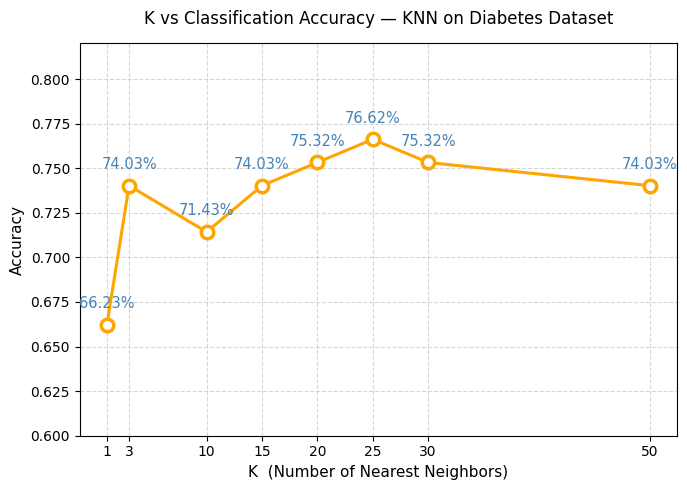

Plot saved as knn_k_vs_accuracy.png


In [36]:
plt.figure(figsize=(7, 5))

plt.plot(k_values, accuracies, marker='o', color='orange',
         linewidth=2.2, markersize=9, markerfacecolor='white',
         markeredgewidth=2.5)

# label each point with its accuracy value
for k, acc in zip(k_values, accuracies):
    plt.annotate(f'{acc*100:.2f}%',
                 xy=(k, acc),
                 xytext=(0, 12),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10.5,
                 color='steelblue')

plt.title('K vs Classification Accuracy — KNN on Diabetes Dataset', fontsize=12, pad=14)
plt.xlabel('K  (Number of Nearest Neighbors)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(k_values)
plt.ylim(0.60, 0.82)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('knn_k_vs_accuracy.png', dpi=150)
plt.show()
print("Plot saved as knn_k_vs_accuracy.png")